### Whats this about:
This notebook explores working with actigraphy time series recordings to get an idea of the data at hand.
- Investigate data quality (e.g., time gaps, non-wear periods, battery issues)
- Calculate main statistics for all participants
- Derive meaningful insights for feature engineering (circadian rhythms, time-based activity trends, activity levels, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

Function to plot ENMO, Angle Z, Light and any other column on below each other.

Yes. With this **specific HBN actigraphy dataset**, we can be much more precise.

### ENMO

In your dataset, `enmo` is calculated from the three acceleration signals:

* `X`
* `Y`
* `Z`

The basic calculation is:

[
ENMO = \max\left(0,\sqrt{X^2+Y^2+Z^2}-1\right)
]

where X, Y, Z are measured in **g-force**.

The important part is **"minus one"**.

Why subtract 1?

Because gravity is approximately **1 g**. Even when the child is completely still, the accelerometer measures Earth's gravity.

For example, imagine the watch is sitting still:

```text
X = 0.00
Y = 0.00
Z = 1.00
```

Then:

[
\sqrt{0^2+0^2+1^2}=1
]

Therefore:

[
ENMO = 1-1=0
]

So `enmo ≈ 0` indicates **little/no movement**.

If the wrist starts moving, the acceleration magnitude changes and ENMO increases.

### What ENMO means in your dataset

Think of it as:

> **ENMO = "How much movement is happening at the wrist?"**

For example:

```text
enmo = 0.000   → essentially no movement
enmo = 0.005   → very little movement
enmo = 0.050   → more movement
enmo = 0.300   → substantial movement
```

The exact interpretation should depend on the distribution of your data rather than fixed thresholds.

---

# Angle-Z

This one is different.

Your dataset specifically defines:

> **Angle-Z = angle of the arm relative to the horizontal plane.**

So it is primarily describing **arm orientation**, not movement intensity.

Imagine the child's arm:

```text
             Arm
              /
             /     ← tilted
            /
-----------/------------ Horizontal plane
```

The `anglez` value tells you something about **that tilt**.

For example, conceptually:

```text
Arm horizontal
--------------------    → anglez near a horizontal reference

Arm tilted
       /
      /
-----/----------------  → different anglez

Arm more upright
      |
      |
------|--------------    → different anglez
```

So:

### `enmo` vs `anglez`

| Column          | Think of it as      | Main information                                 |
| --------------- | ------------------- | ------------------------------------------------ |
| `X`, `Y`, `Z`   | Raw acceleration    | What the accelerometer experiences               |
| `enmo`          | **Movement amount** | How active/moving the wrist is                   |
| `anglez`        | **Arm orientation** | How the arm is positioned relative to horizontal |
| `non-wear_flag` | Watch status        | Whether watch is probably being worn             |

---

## Why having both is useful

Suppose you see:

```text
time       enmo     anglez
10:00      0.002    85
10:05      0.003    86
10:10      0.004    85
```

The `enmo` is very low and `anglez` is almost unchanged.

That suggests:

> **The arm is relatively still and maintaining approximately the same orientation.**

Now suppose:

```text
time       enmo     anglez
10:00      0.002    85
10:05      0.080    40
10:10      0.150    -10
```

Now both are changing.

That suggests:

> **There is substantial wrist movement and the arm orientation is changing.**

---

### One important distinction

Don't interpret `anglez` as:

> "How much the person is moving."

That's what `enmo` is much closer to measuring.

Instead:

**ENMO → movement intensity**

**Angle-Z → arm position/orientation**

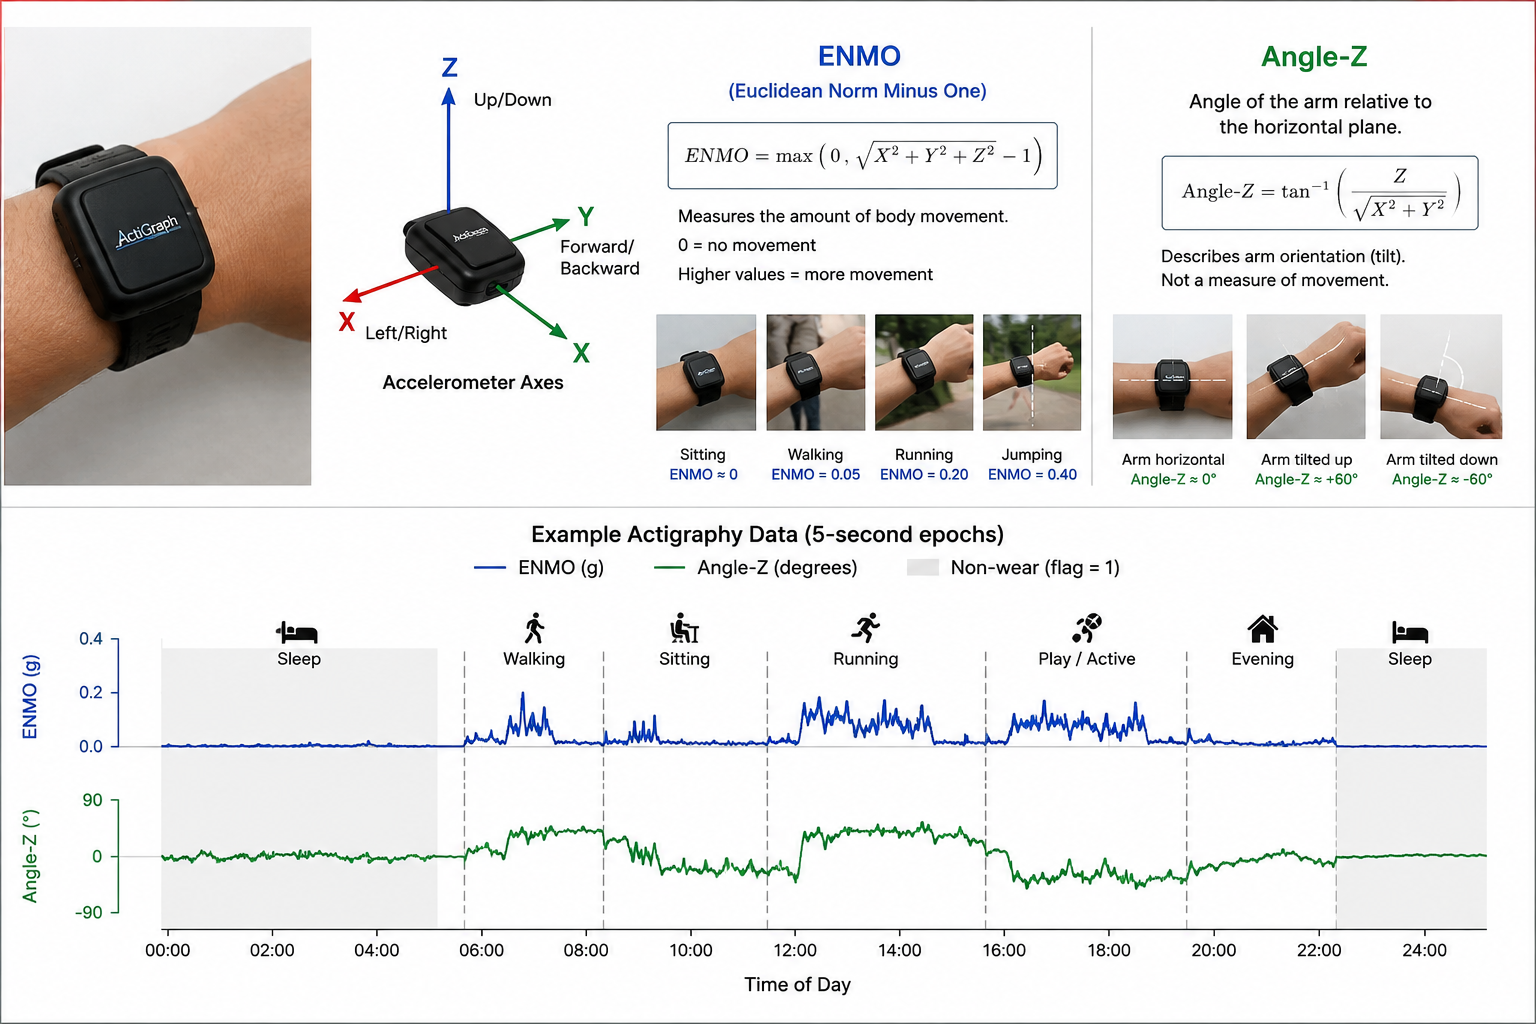

**`light` means the amount of ambient light detected by the watch**, measured in **lux (lx)**.

Think of it as:

> **`light` = "How bright is the environment around the wrist?"**

### Visual idea

![Image](https://images.openai.com/static-rsc-4/iRD_p0gW6s7VMHtE2Cdhw0FGpalxEPdOazpvJw8kjRBGyna2wh3xyBzcyDwTJNemLa7FPyYx6USqewSHIVNhsZPrH-dxUh_h-p_RKakR39qRlAdZa0z0XorUDjn2pC9P477AzGDMKEh0_NQlOQpkLytYBnAJHQQbRxU8cRPwK7MtWEpLcroA1Iuxe37bWUrd?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/dRbC1sFlKKkYyBDFfe6O7LE9q-ljOtBEZ5QH8irARapWwseuYmlw_0vK0DWuB4R3ZiBBnBAqQ_009DKqrAOJg0yrUdDvCSyxiqZfjInpM5Oy8bmfKsMVnLadzWiY2r2k3Jh_Bh2fbLy7WeSG9-v1x7nsYkCDkE-bkhO9qsKR_1CG6JZ_GRr_6T4ZQEjk2Vjh?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/DvwW0oLSaGRKxqsu0EC4D3uR31xS4HcixMED_eSUndr2Em-NU84-URH9JizgmLA0jLc_zFoBnijjVeksocbQuQpn_huwqMbFNRTlbMCCZbQpRhgdtrDkjkYGGZ84CpSroA1mVA06DUVug5qtJ9h0chEIbDC1E3WKeSLe3dDMoaA2mRVgdV_2Wd2AyWsGG3lE?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/YxoBikWGGqD-qHvNibXXvzDrR0j7D2TSQLNMVm5qzovzeTPtyJnBwzThljJXUhH9vozsBGdM2jOlENCBDcXccrlUS8g9kFgUsyF5q2WwiGVrLL6owDR8UVvFJa9EvGhlewsqNkK-oSlMonGBbIEi6YftAXSA1y0V7HBK8fGNHaBhYoFagmKSTpRBQtmurI2u?purpose=fullsize)

### What does lux mean?

**Lux measures illuminance** — how much visible light is reaching a surface.

Roughly:

| Environment            | Approximate light |
| ---------------------- | ----------------: |
| Dark room              |          ~0–1 lux |
| Dim room               |           ~10 lux |
| Normal indoor room     |      ~100–500 lux |
| Bright indoor lighting |    ~500–1,000 lux |
| Overcast outdoors      | ~1,000–10,000 lux |
| Bright sunlight        |       10,000+ lux |

These are **rough examples**, not fixed thresholds for your dataset.

### How it differs from ENMO and Angle-Z

Your watch is collecting several different types of information simultaneously:

```text
                 WRIST WATCH
                     │
        ┌────────────┼────────────┐
        ↓            ↓            ↓
   Accelerometer   Light       Other sensors
        │            │
   ┌────┼────┐       │
   X    Y    Z       lux
   │    │    │       │
   └────┬────┘       │
        ↓            ↓
      ENMO         brightness
        │
   movement level
```

So:

* **`ENMO`** → How much is the wrist moving?
* **`anglez`** → How is the arm oriented?
* **`light`** → How bright is the surrounding environment?
* **`non-wear_flag`** → Is the watch probably being worn?

### Why is `light` useful?

This becomes particularly interesting when analyzing **sleep and daily behavior**.

For example:

```text
Time        ENMO       Light
──────────────────────────────
10 PM       very low   5 lux
11 PM       very low   2 lux
12 AM       very low   0 lux
 1 AM       very low   0 lux
 7 AM       increasing 50 lux
 8 AM       higher     500 lux
```

This pattern could indicate:

**dark + little movement → sleep/night**

followed by

**increasing light + increasing movement → waking/morning activity**

But you should **not automatically classify sleep from `light` alone**. You would normally combine `light`, `ENMO`, `anglez`, time of day, and potentially other features.

### One very important point

`light` is **not the brightness of the watch screen** and it is **not a measure of physical activity**.

It's a measurement of **ambient illumination detected by the wearable's light sensor**, expressed in lux.

For your ML/EDA work, you can think of the three main signals like this:

> 🏃 **ENMO → movement**
> 🧍 **Angle-Z → body/arm orientation**
> 💡 **Light → environmental brightness**

That combination can be quite useful for understanding **when, where, and under what conditions activity occurs**.


In [2]:
def plot_series_data(df, col='non-wear_flag',
                     label='Worn (0 = Worn, 1 = Not Worn)',
                     title='Non-Wear Flag',
                     x_col='day_time', x_label='Day Relative to PCIAT + Time'):
    plt.figure(figsize=(18, 12))
    
    # ENMO
    plt.subplot(4, 1, 1)
    plt.scatter(df[x_col], df['enmo'], label='ENMO', color='green', s=1)
    plt.title('ENMO (Euclidean Norm Minus One)')
    plt.ylabel('Movement Intensity')

    # Angle Z
    plt.subplot(4, 1, 2)
    plt.scatter(df[x_col], df['anglez'], label='Angle Z', color='blue', s=1)
    plt.title('Angle Z')
    plt.ylabel('Angle (degrees)')

    # Light
    plt.subplot(4, 1, 3)
    plt.scatter(df[x_col], df['light'], label='Light', color='orange', s=1)
    plt.title('Ambient Light')
    plt.ylabel('Light (lux)')

    # Any other column
    plt.subplot(4, 1, 4)
    plt.scatter(df[x_col], df[col], label=col, color='red', s=1)
    plt.title(f'{title}')
    plt.ylabel(f'{label}')
    plt.xlabel(f'{x_label}')

    plt.tight_layout()
    plt.show()

## One participant data preview

In [3]:
train = pd.read_csv(r'..\data\child-mind-institute-problematic-internet-use\train.csv')

In [4]:
path = '..\data\child-mind-institute-problematic-internet-use\series_train.parquet\id=0417c91e'
series_train = pd.read_parquet(path)
series_train

,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,0.014375,-0.020112,-0.995358,0.001060,-88.445251,0.0,41.000000,4195.000000,44100000000000,2,2,5.0
1,1,0.014167,-0.023278,-0.996164,0.000289,-88.372200,0.0,41.000000,4194.833496,44105000000000,2,2,5.0
2,2,0.014036,-0.022964,-0.996320,0.000301,-88.356422,0.0,41.500000,4194.666504,44110000000000,2,2,5.0
3,3,0.013593,-0.022048,-0.996762,0.002278,-88.575943,0.0,37.500000,4194.500000,44115000000000,2,2,5.0
4,4,-0.061772,-0.065317,-0.973063,0.092321,-88.391273,0.0,55.666668,4199.000000,44780000000000,2,2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287174,287174,-0.407433,0.091612,-0.377763,0.039733,-43.319416,0.0,7.000000,3695.000000,32875000000000,1,3,53.0
287175,287175,-0.703572,0.016187,0.159560,0.035980,14.121390,0.0,7.000000,3695.000000,32880000000000,1,3,53.0
287176,287176,-0.209607,-0.469700,0.636573,0.097799,44.998573,0.0,7.000000,3695.000000,32885000000000,1,3,53.0
287177,287177,-0.390378,0.284386,0.147654,0.057826,7.726313,0.0,7.000000,3695.000000,32890000000000,1,3,53.0


The description of the actigraphy data columns and comments below each one:

series_{train|test}.parquet/id={id} - Series to be used as training data, partitioned by id. Each series is a continuous recording of accelerometer data for a single subject spanning many days.

- id - The patient identifier corresponding to the id field in train/test.csv.
- step - An integer timestep for each observation within a series. Corresponds to sequential data collection points.

- X, Y, Z - Measure of acceleration, in g, experienced by the wrist-worn watch along each standard axis.
The three-dimensional accelerometer readings, describe the physical movement of the person wearing the device

- enmo - As calculated and described by the wristpy package, ENMO is the Euclidean Norm Minus One of all accelerometer signals (along each of the x-, y-, and z-axis, measured in g-force) with negative values rounded to zero. Zero values are indicative of periods of no motion. While no standard measure of acceleration exists in this space, this is one of the several commonly computed features.

A scalar value for the level of motion, where higher values indicate more activity, and zeros - of no motion

- anglez - As calculated and described by the wristpy package, Angle-Z is a metric derived from individual accelerometer components and refers to the angle of the arm relative to the horizontal plane.

Provide information about posture or how the arm is positioned during the activity

- non-wear_flag - A flag (0: watch is being worn, 1: the watch is not worn) to help determine periods when the watch has been removed, based on the GGIR definition, which uses the standard deviation and range of the accelerometer data.

Would be great to know how it was calculated.

- light - Measure of ambient light in lux. See [here](https://actigraphcorp.my.site.com/support/s/article/Lux-Measurements) for details.
May help distinguish between different times of day (day vs. night) or types of activities (e.g., being indoors or outdoors)

- battery_voltage - A measure of the battery voltage in mV.

Unlikely to be important for modeling, but may help in identifying issues related to the data collection process (low battery voltage might align with gaps, inconsistencies, or interruptions in the data)

- time_of_day - Time of day representing the start of a 5s window that the data has been sampled over, with format %H:%M:%S.%9f.

Again as @AmbrosM have been already said, this description is not true. Time of the day was measured in nanoseconds since midnight.

- weekday - The day of the week, coded as an integer with 1 being Monday and 7 being Sunday.

This could provide insights into behavior patterns during weekdays versus weekends

- quarter - The quarter of the year, an integer from 1 to 4.

Could be relevant if there are seasonal patterns in activity (e.g., more outdoor activity in summer)

- relative_date_PCIAT - The number of days (integer) since the PCIAT test was administered (negative days indicate that the actigraphy data has been collected before the test was administered).

The mentioned Wristpy package is here: [Wrist-Worn Accelerometer Data Processing](https://github.com/childmindresearch/wristpy)

In [5]:
participant_id = path.split('\\')[-1].split('=')[-1]
participant_id

'0417c91e'

In [6]:
train[train['id'] == participant_id]

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
68,0417c91e,Spring,6,1,Winter,40.0,Summer,15.484507,45.5,45.6,...,0.0,0.0,0.0,11.0,NaN,NaN,NaN,Summer,0.0,0.0


Plot data by steps:

So we'll look at the data collected from a 6-year-old girl, with no data on sleep or activity based on Physical Activity Questionnaire, who spends no time on the Internet and has an SII of 0.

Her physical data includes a BMI of 15.48, height of 45.5 inches, and weight of 45.6 pounds, normal blood pressure readings (Systolic: 115, Diastolic: 73), and a heart rate of 86 bpm

The fitness endurance test shows a max stage of 6, with a duration of 9 minutes and 5 seconds.

The girl completed a small number of curl-ups, no push-ups, and had moderate sit-and-reach flexibility on both sides. There is missing data for grip strength tests, and the participant's trunk lift performance is in zone 1.0

A CGAS score of 40 suggests that the child has significant impairment in daily functioning

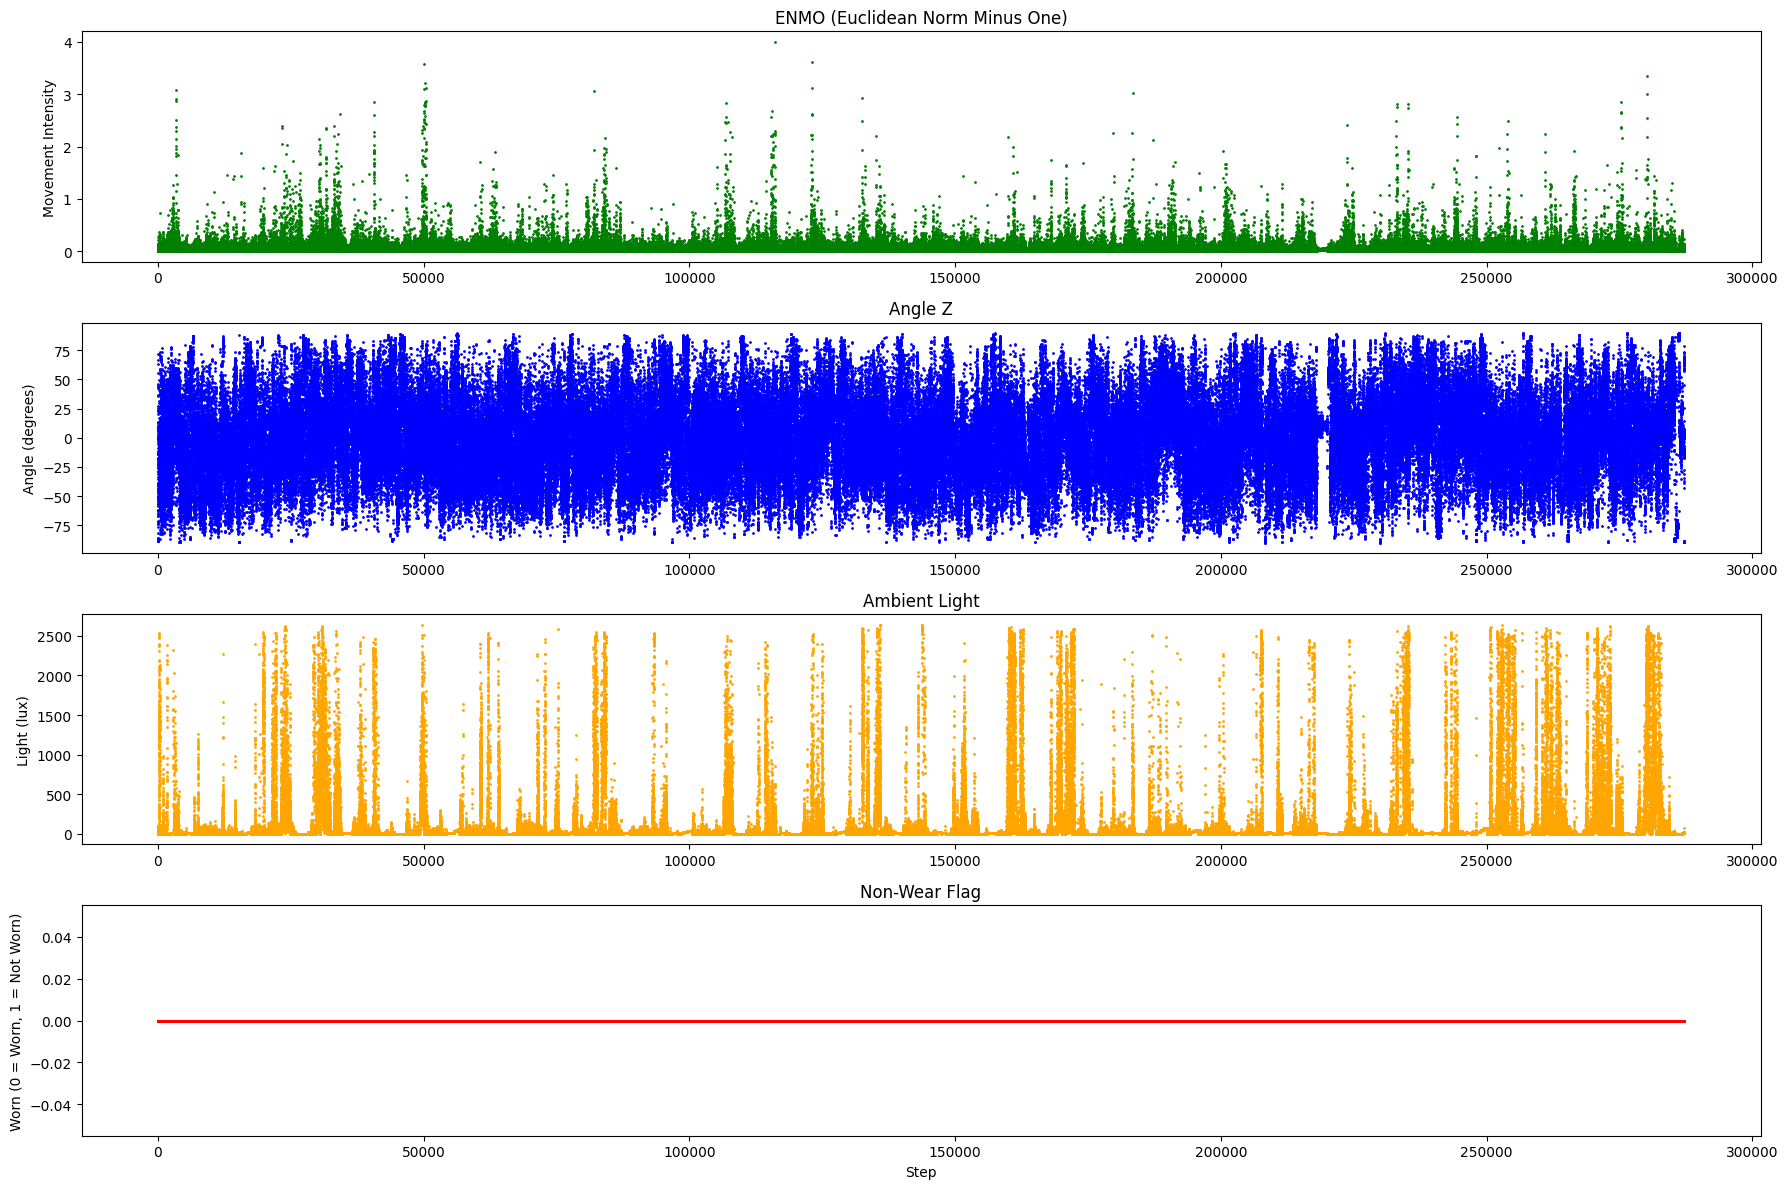

In [7]:
plot_series_data(series_train, x_col='step', x_label='Step')

 Note: Looks ok, and the wear flag looks correct (always indicating that the device was worn). But when using the step column as the x-axis, the time points are assumed to be equidistant, meaning that each step represents a uniform interval (e.g., every 5 seconds). But in reality, there may be irregular time gaps between data points.
 
Create a continuous time scale in days by transforming the time_of_day column (which is in nanoseconds) to hours and then combining it with relative_date_PCIAT:

In [8]:
series_train['time_of_day_hours'] = (
    series_train['time_of_day'] / 1e9 / 3600 #nanoseconds to hours
)
series_train['day_time'] = series_train['relative_date_PCIAT'] + (
    series_train['time_of_day_hours'] / 24
)
series_train['day_time']

0          5.510417
1          5.510475
2          5.510532
3          5.510590
4          5.518287
            ...    
287174    53.380498
287175    53.380556
287176    53.380613
287177    53.380671
287178    53.380729
Name: day_time, Length: 287179, dtype: float64

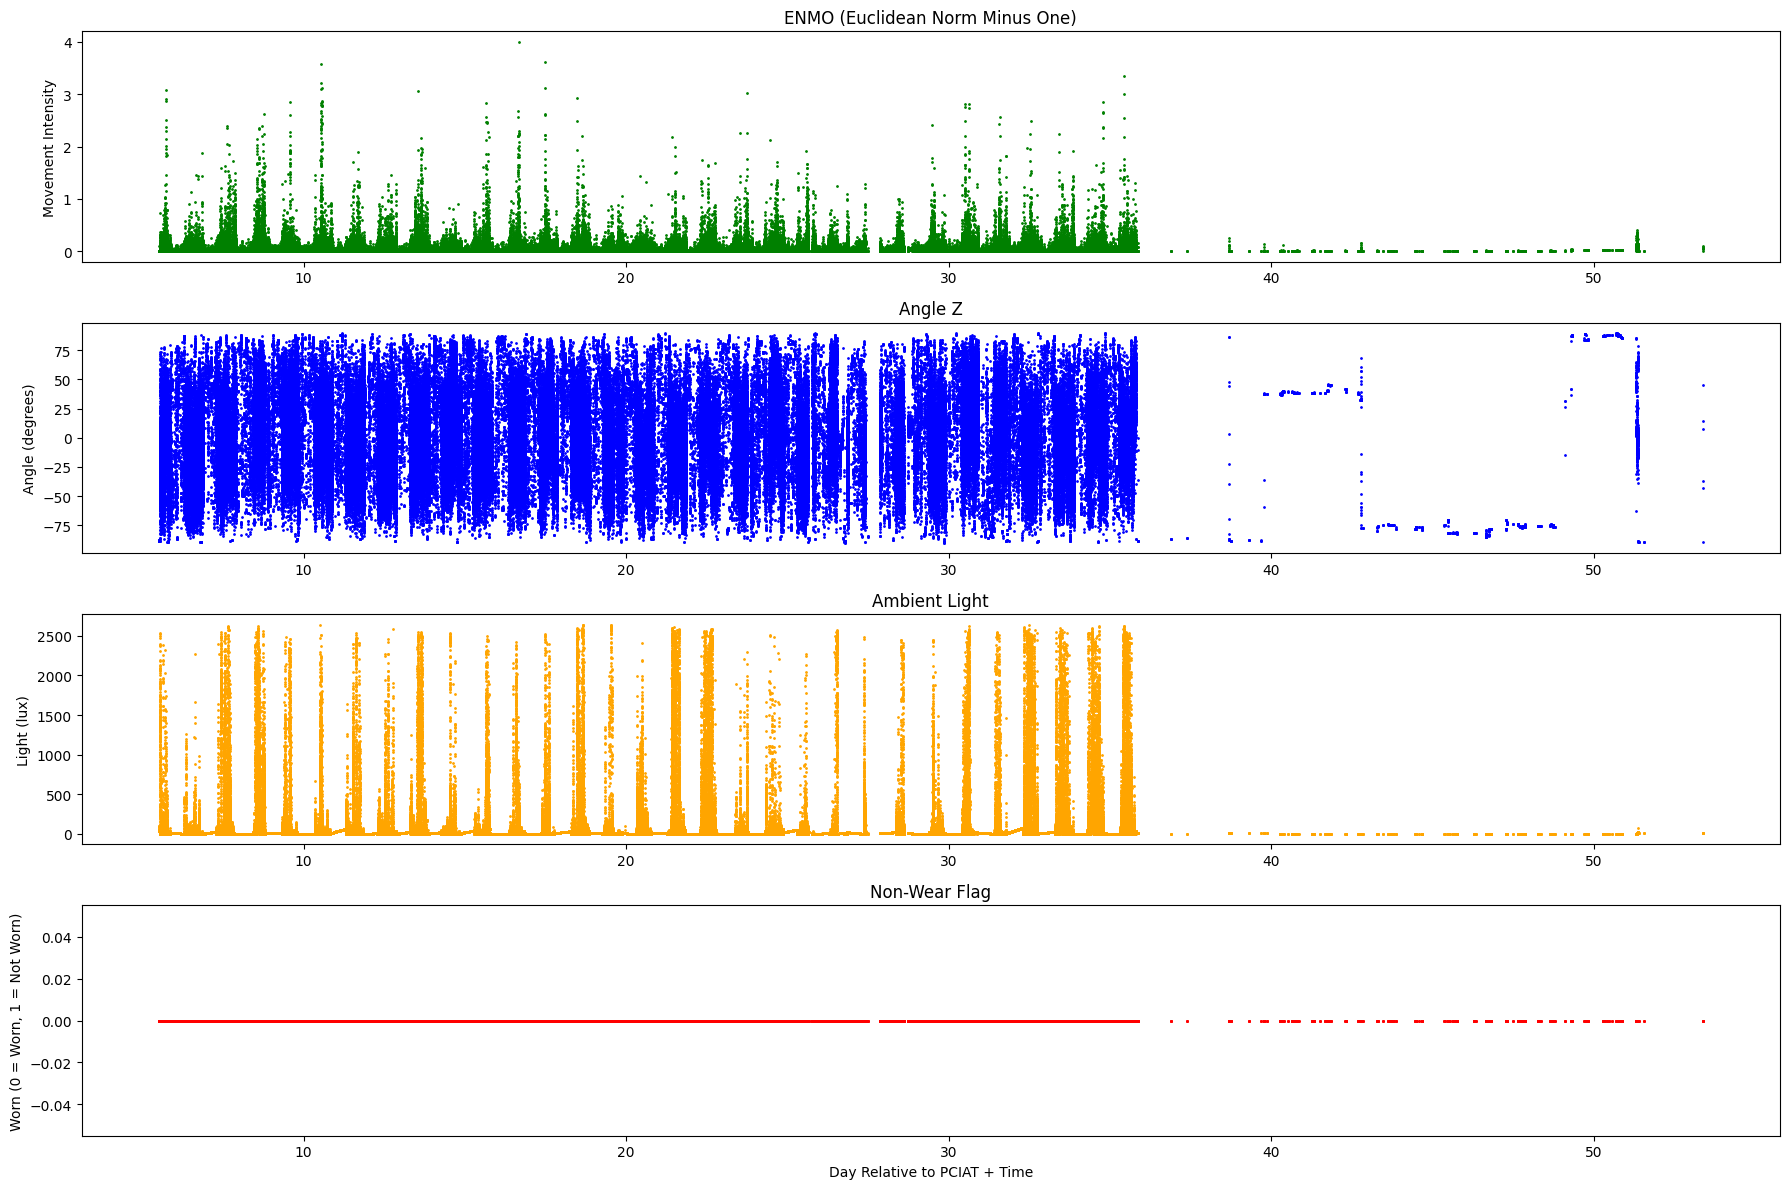

In [9]:
plot_series_data(series_train, x_col='day_time', x_label='Day Relative to PCIAT + Time')

In [10]:
len(series_train[series_train['relative_date_PCIAT'] > 36])

1830

Note: Here, the data is plotted with real time on the x-axis, revealing gaps (especially on the right end) - the data for a few last weeks (after day 36) is only 1,830 measurements out of 287,179. These gaps suggest that some data was either not collected at all or was intentionally cut. Let's zoom in.

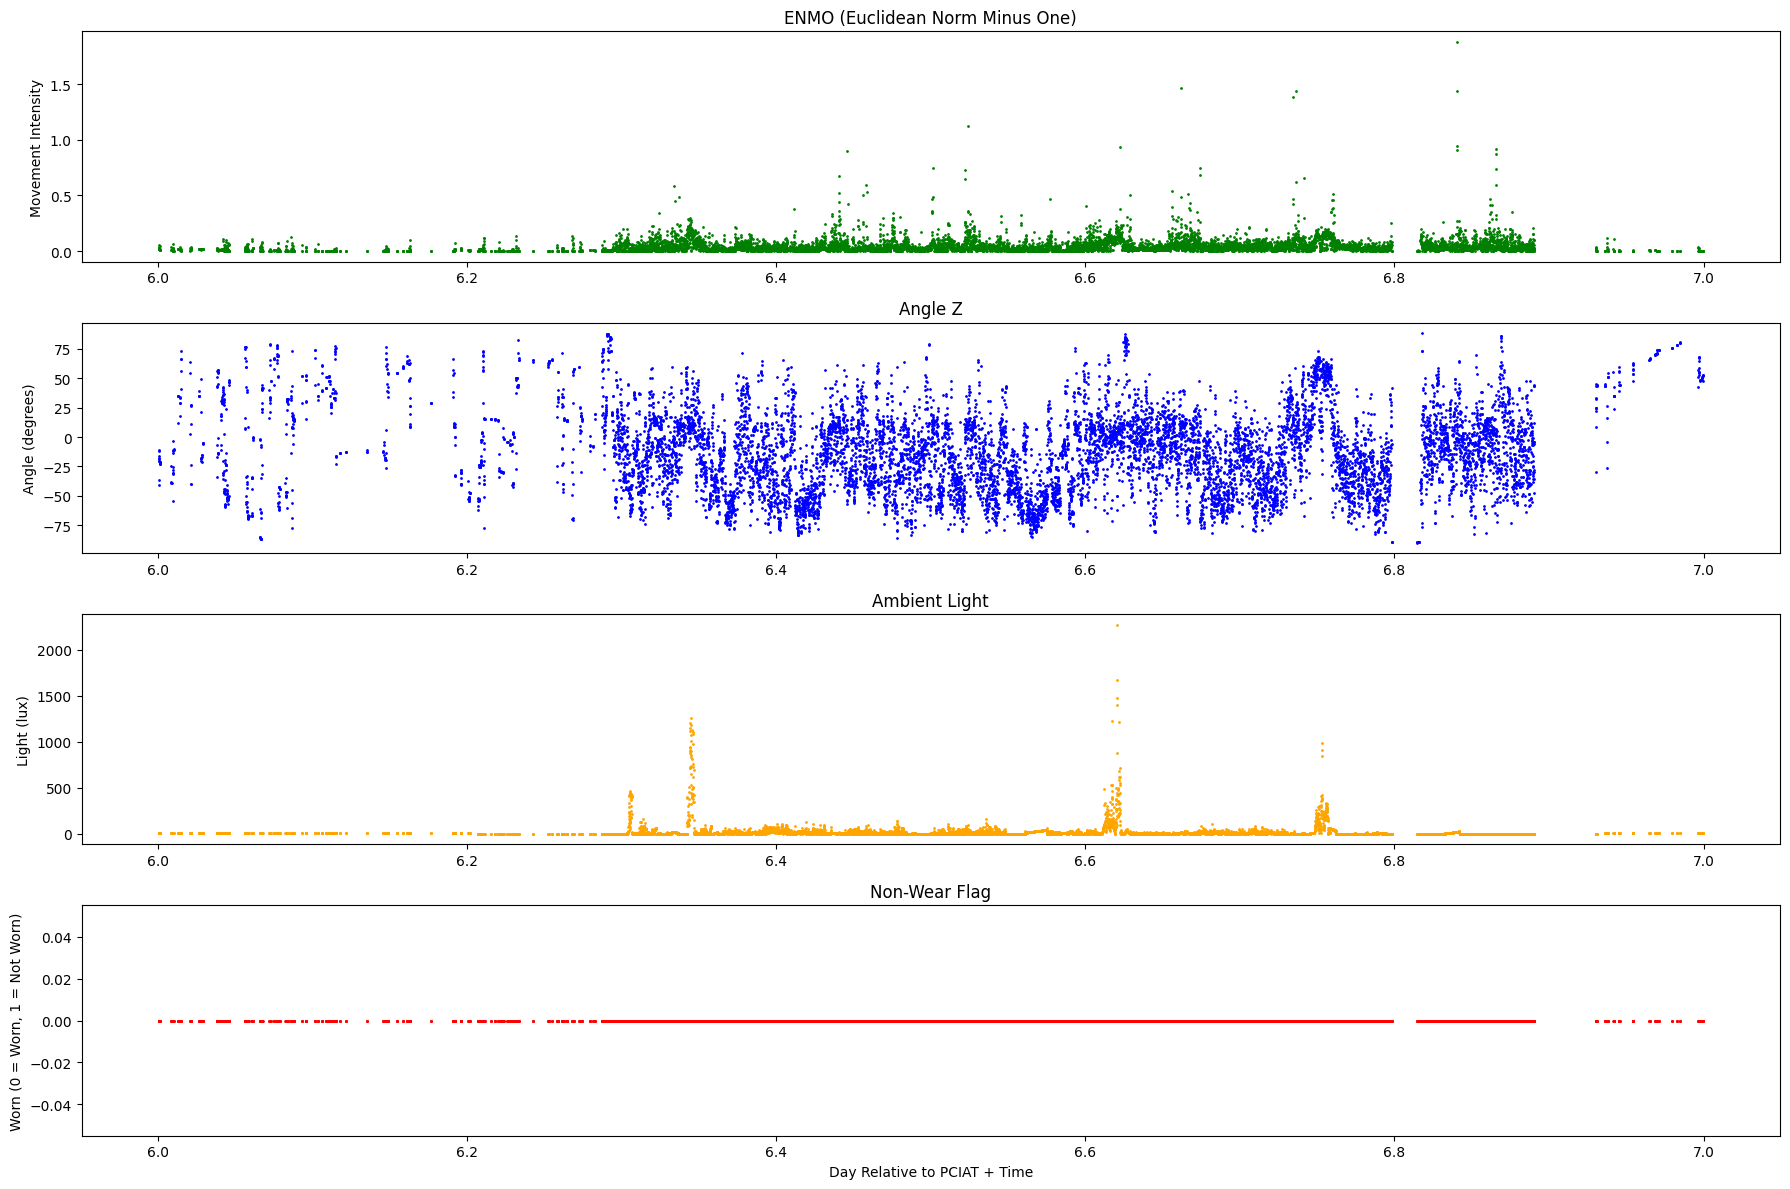

In [11]:
start_day = 2 # second day of wearing the device
show_days = 1

first_day = min(series_train['relative_date_PCIAT']) + start_day - 1
filtered_data = series_train[
    (series_train['relative_date_PCIAT'] >= first_day) &
    (series_train['relative_date_PCIAT'] <= first_day + show_days - 1)
].copy()

plot_series_data(filtered_data)

Note:
The left part of the plot likely represents sleep time.
The activity level peaks in the middle of the day.
The spikes in the ENMO, Angle Z, and Ambient Light suggest short bursts of activity that may correspond to specific tasks or movements, but there are many periods of low or no movement, and the overall pattern of activity appears to be consistent with significant impairment in daily functioning according to the CGAS score.
For a healty child of this age, you would generally expect to see more consistent periods of active movement throughout the day, especially during the daytime hours when children typically play, run, etc.

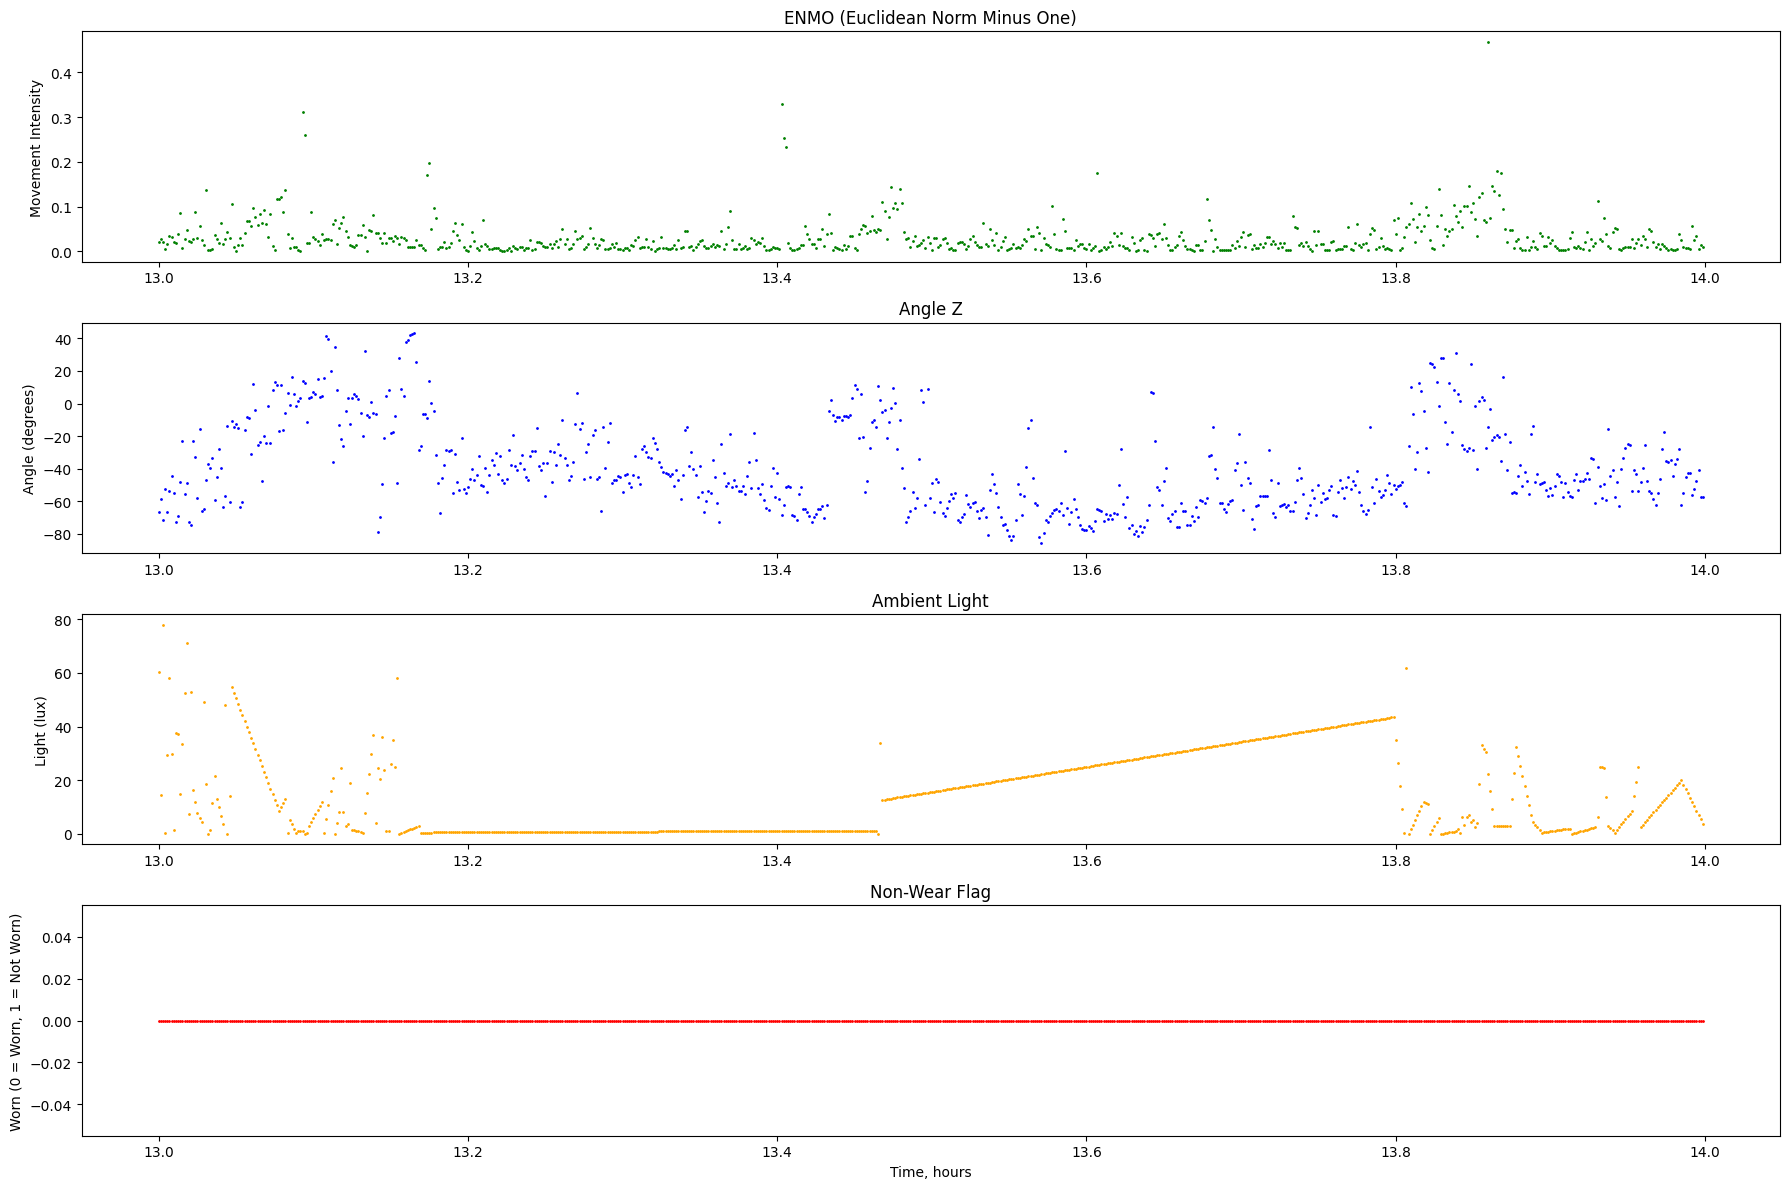

In [12]:
show_day = 2 # show second day
hour_from = 13 # starting from 1 pm
hour_to = 14 # to 2 pm

show_day = min(series_train['relative_date_PCIAT']) + show_day - 1
filtered_data = series_train[
    (series_train['relative_date_PCIAT'] == show_day) &
    (series_train['time_of_day_hours'] >= hour_from) & 
    (series_train['time_of_day_hours'] < hour_to)
].copy()

plot_series_data(filtered_data, x_col='time_of_day_hours', x_label='Time, hours')

 Note:
The ENMO (Euclidean Norm Minus One) shows small but continuous movement, and there are changes in orientation, indicating that even minor movements are detected, which can be interpreted as the device being worn.
The same is true if we look at any day within the last 2 weeks, where there are few measurements left, yet the worn flag seems to align well with movement patterns.
The light data in this part of the plot does not look completely consistent or reliable, especially because of the flatline, linear trend in the middle and sudden changes (data processing artifacts?).
Maybe the data has been truncated for periods of low battery? Let's check the battery voltage over time.

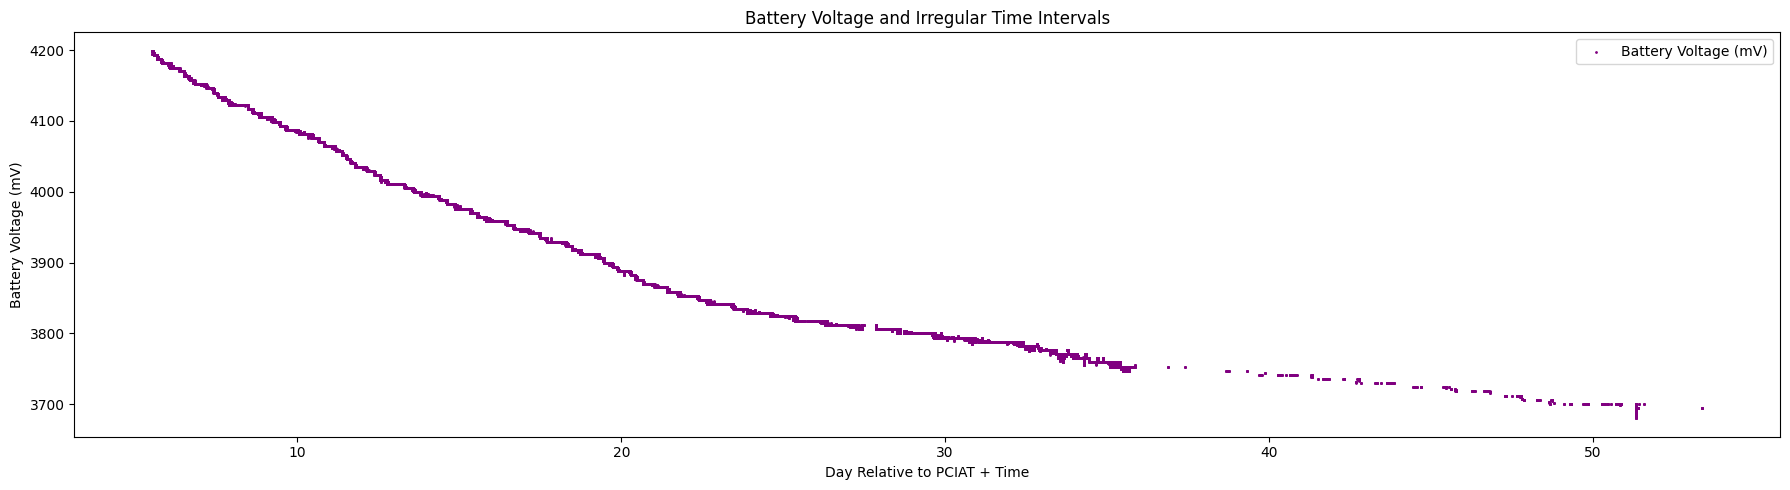

In [13]:
plt.figure(figsize=(18, 5))

plt.scatter(series_train['day_time'], series_train['battery_voltage'], 
            color='purple', label='Battery Voltage (mV)', s=1)

plt.xlabel('Day Relative to PCIAT + Time')
plt.ylabel('Battery Voltage (mV)')
plt.title('Battery Voltage and Irregular Time Intervals')
plt.legend()

plt.tight_layout()
plt.show()

Note: The battery did not seem to run out completely at the end. I guess, the smooth decline suggests that the device was likely functioning properly during this time.

### Day/nigth periods

Use the time data to categorize the day and night. Daytime is set between 8 AM and 9 PM.

In [14]:
day_start_hour = 8
day_end_hour = 21

series_train['day_period'] = np.where(
    (series_train['time_of_day_hours'] >= day_start_hour) &
    (series_train['time_of_day_hours'] < day_end_hour),
    'day', 'night'
)

C:\Users\adity\AppData\Local\Temp\ipykernel_10372\3336426313.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
d:\Kaggle\ProblematicInternetUse\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


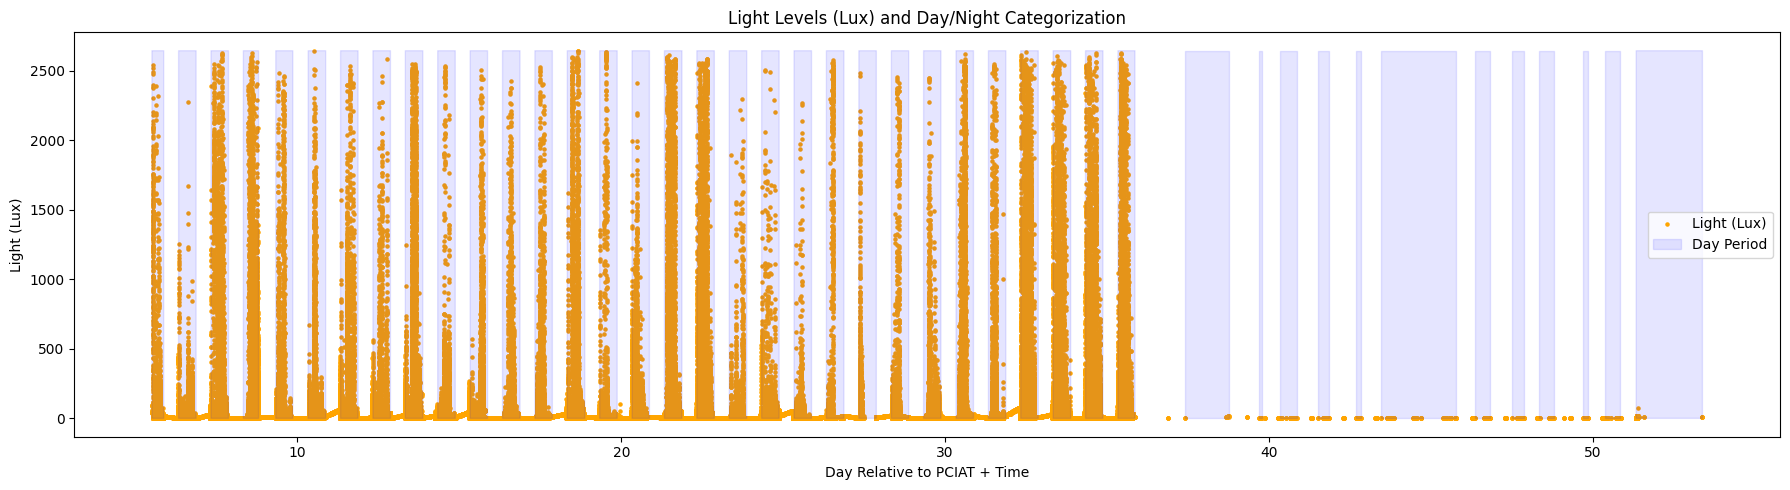

In [15]:
plt.figure(figsize=(18, 5))

plt.scatter(series_train['day_time'], series_train['light'], label='Light (Lux)', 
         color='orange', s=5)

plt.fill_between(series_train['day_time'],
                 0, series_train['light'].max(),
                 where=(series_train['day_period'] == 'day'),
                 color='blue', alpha=0.1, label='Day Period')

plt.title('Light Levels (Lux) and Day/Night Categorization')
plt.ylabel('Light (Lux)')
plt.xlabel('Day Relative to PCIAT + Time')
plt.legend()

plt.tight_layout()
plt.show()

Note: The purple areas (representing the day period) toward the end of the timeline appear stretched and irregular, but we already know that a number of records have been cut from the data.

Time difference between steps

From the description, time_of_day should represent the start of a 5s window over which the data was sampled. But in the plots above, we saw that time periods can be irregular. Let's check this out.

In [16]:
expected_diff = 5

series_train['time_diff'] = (series_train['day_time'].diff() * 86400).round(0) # seconds in a day
series_train['measurement_after_gap'] = series_train['time_diff'] > expected_diff
series_train['measurement_after_gap'].value_counts()

measurement_after_gap
False    281762
True       5417
Name: count, dtype: int64

5417 readings for this participant are off by more than 5 seconds.

In [17]:
series_train['time_diff'].describe()

count    287178.000000
mean         14.402200
std         523.719089
min           5.000000
25%           5.000000
50%           5.000000
75%           5.000000
max      156445.000000
Name: time_diff, dtype: float64

In [18]:
156445 / 60 / 60 # sec to hours

43.45694444444444

Note: There are many time gaps >5s and the maximum time gap between measurements is 43 hours.

Main Statistics for all Participants

 calculate the percentage of rows with wear flag = 1 (device not worn) and the main statistics for key parameters for periods when the device was worn, ignoring time gaps, to get an idea of the values distributions.

In [19]:
DIR = '../data/child-mind-institute-problematic-internet-use/series_train.parquet'

def process_file(file_path, participant_id):
    data = pd.read_parquet(file_path)
    non_wear_percentage = (data['non-wear_flag'].sum() / len(data)) * 100
    worn_data = data[data['non-wear_flag'] == 0]

    return {
        'id': participant_id,
        'non_wear_percentage': non_wear_percentage,
        'enmo_stats': worn_data['enmo'].describe(),
        'anglez_stats': worn_data['anglez'].describe(),
        'light_stats': worn_data['light'].describe(),
        'battery_voltage_stats': worn_data['battery_voltage'].describe(),
        'unique_days': worn_data['relative_date_PCIAT'].nunique()
    }

results = []
for participant_id in os.listdir(DIR):
    file_path = os.path.join(DIR, participant_id, 'part-0.parquet')
    result = process_file(file_path, participant_id)
    results.append(result)

In [20]:
final_results = []
for result in results:
    flat_row = {
        'id': result['id'].replace('id=', ''),
        'non_wear_percentage': result['non_wear_percentage'],
        'unique_days': result['unique_days']
    }
    
    for key, stats in result.items():
        if isinstance(stats, pd.Series):
            for stat_name, stat_value in stats.items():
                flat_row[f'{key.replace("_stats", "")}_{stat_name}'] = stat_value
    
    final_results.append(flat_row)
    
stats_df = pd.DataFrame(final_results)
stats_df

,id,non_wear_percentage,unique_days,enmo_count,enmo_mean,enmo_std,enmo_min,enmo_25%,enmo_50%,enmo_75%,...,light_75%,light_max,battery_voltage_count,battery_voltage_mean,battery_voltage_std,battery_voltage_min,battery_voltage_25%,battery_voltage_50%,battery_voltage_75%,battery_voltage_max
0,00115b9f,0.000000,40,43330.0,0.047388,0.106351,0.0,0.006432,0.023637,0.041420,...,15.000000,2633.250000,43330.0,4053.579102,112.404045,3824.000000,4028.666748,4070.0,4147.000000,4188.5
1,001f3379,65.570793,24,129316.0,0.016461,0.040610,0.0,0.000845,0.006559,0.015562,...,10.533334,2597.800049,129316.0,3984.540039,153.086365,3098.166748,3947.000000,4000.0,4076.000000,4175.0
2,00f332d1,17.124575,24,341006.0,0.036441,0.113819,0.0,0.001023,0.009548,0.027902,...,18.161591,2611.000000,341006.0,3874.654297,151.311859,3541.000000,3755.500000,3841.0,3994.000000,4187.0
3,01085eb3,3.521038,22,357626.0,0.033677,0.085257,0.0,0.000938,0.007187,0.027710,...,18.274206,2650.500000,357626.0,3866.360596,148.550430,3401.000000,3747.000000,3835.0,3988.000000,4184.0
4,012cadd8,0.000000,7,97048.0,0.058280,0.197285,0.0,0.001604,0.010466,0.038781,...,19.320485,2618.000000,97048.0,3974.910645,119.525154,3095.000000,3940.479187,3994.0,4046.000000,4157.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,fe9c71d8,13.725731,25,365165.0,0.045263,0.111908,0.0,0.001069,0.016409,0.038898,...,4.750000,2527.199951,365165.0,3871.371826,136.905914,3378.000000,3777.000000,3834.5,3976.000000,4183.0
992,fecc07d6,93.910095,11,20845.0,0.015427,0.050504,0.0,0.001303,0.002212,0.003349,...,162.334457,303.701996,20845.0,3940.743652,138.468674,3779.000000,3821.750000,3923.0,3962.416748,4181.0
993,ff18b749,0.000000,23,384900.0,0.053595,0.142568,0.0,0.001506,0.014763,0.053592,...,18.006736,2644.250000,384900.0,3842.762451,163.234406,3098.166748,3741.000000,3812.0,3963.500000,4176.0
994,ffcd4dbd,2.032310,25,407099.0,0.028744,0.073173,0.0,0.000607,0.008500,0.025895,...,14.328227,2605.750000,407099.0,3851.580078,161.214737,3098.166748,3747.000000,3818.0,3970.000000,4185.0


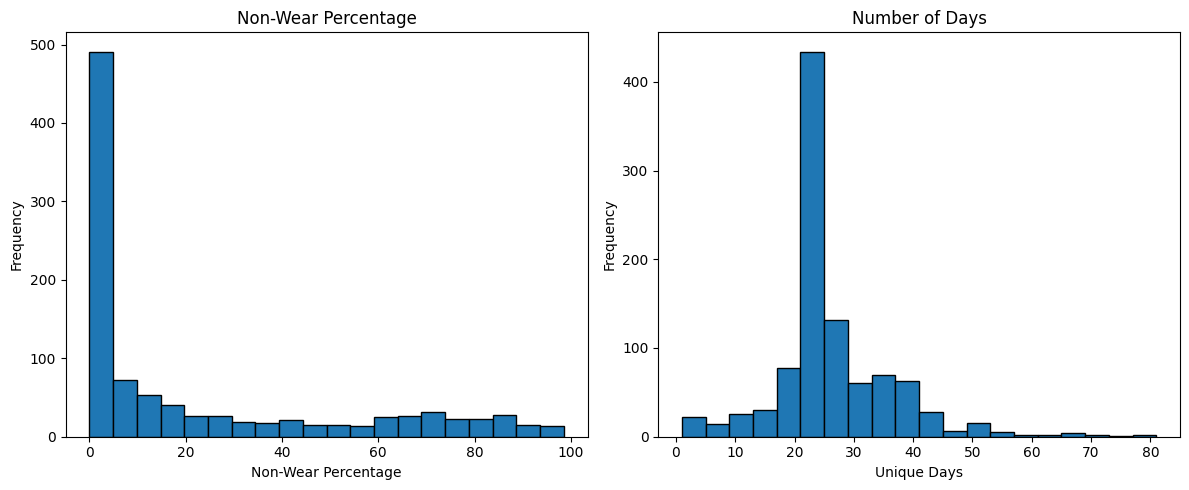

In [21]:
# non_wear_percentage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(stats_df['non_wear_percentage'], bins=20, edgecolor='black')
plt.title('Non-Wear Percentage')
plt.xlabel('Non-Wear Percentage')
plt.ylabel('Frequency')

# unique_days
plt.subplot(1, 2, 2)
plt.hist(stats_df['unique_days'], bins=20, edgecolor='black')
plt.title('Number of Days')
plt.xlabel('Unique Days')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
stats_df[['non_wear_percentage', 'unique_days']].describe()

,non_wear_percentage,unique_days
count,996.000000,996.000000
mean,22.199020,25.892570
std,29.751493,9.950506
min,0.000000,1.000000
25%,0.000000,22.000000
50%,5.145835,24.000000
75%,39.636219,29.000000
max,98.515526,81.000000


Note:
- In total we have actigraphy data for 996 participants
- The description says that "During their participation in the HBN study, some participants were given an accelerometer to wear for up to 30 days continually while at home and going about their regular daily lives", but we can see that participants actually wore the device from 1 to 81 days. Half of them wore it for 24 days or less.

Let's make simple plots to get a general overview of the variability in min, max, median, and std across the parameters (enmo, anglez, light, and battery_voltage)

In [23]:
def plot_parameter_statistics(stats_df, parameter):
    stats_to_plot = ['min', 'max', '50%', 'std']
    stat_labels = ['Min', 'Max', 'Median', 'Std']

    plt.figure(figsize=(14, 5))

    for j, stat in enumerate(stats_to_plot):
        plt.subplot(1, 4, j + 1)
        
        data = stats_df[f'{parameter}_{stat}']
        plt.hist(data, bins=20, alpha=0.7, edgecolor='black')
        
        plt.title(f'{parameter.capitalize()} - {stat_labels[j]}')
        plt.xlabel('Values')
        plt.ylabel('Frequency')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

ENMO

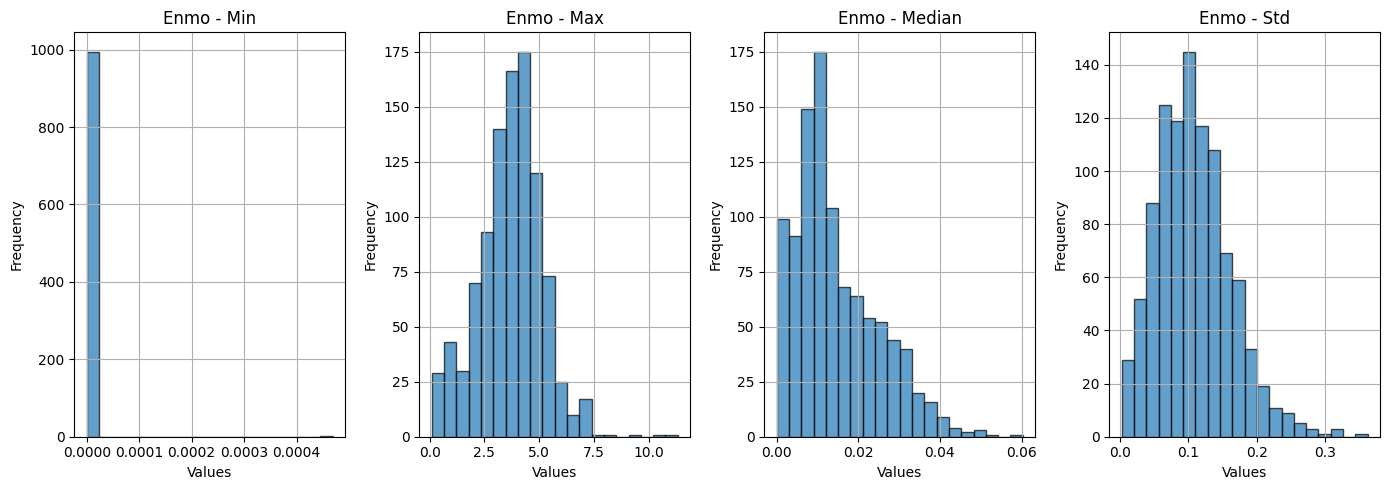

In [24]:
plot_parameter_statistics(stats_df, 'enmo')

Note:
- There are participants without no movement periods because the minimum value can be non-zero.
- Most max values are between 2 and 6, but some go up to 10 or more, and apparently there are participants not moving at all? (as max can be around 0)

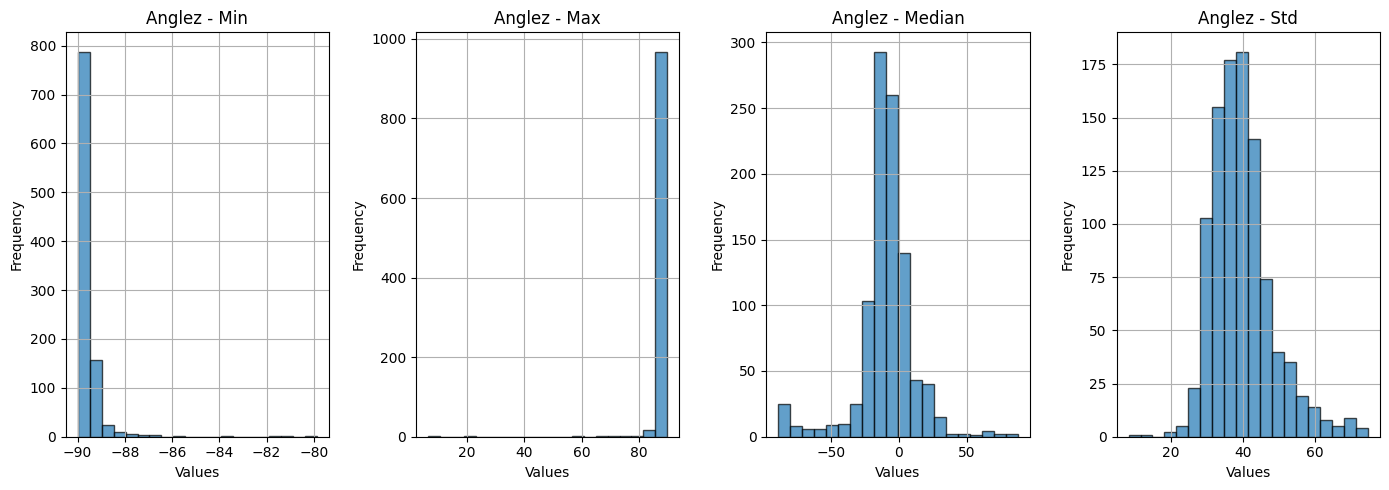

In [25]:
plot_parameter_statistics(stats_df, 'anglez')

Note:
- Angle Z in actigraphy generally measures the vertical orientation or tilt of the wrist along the z-axis, which is typically aligned with the forearm’s longitudinal axis. Given that the device is fixed to the wrist, this angle provides information on how the wrist is rotated vertically (up or down).
- I think, these results make sense considering normal wrist movements throughout the day.

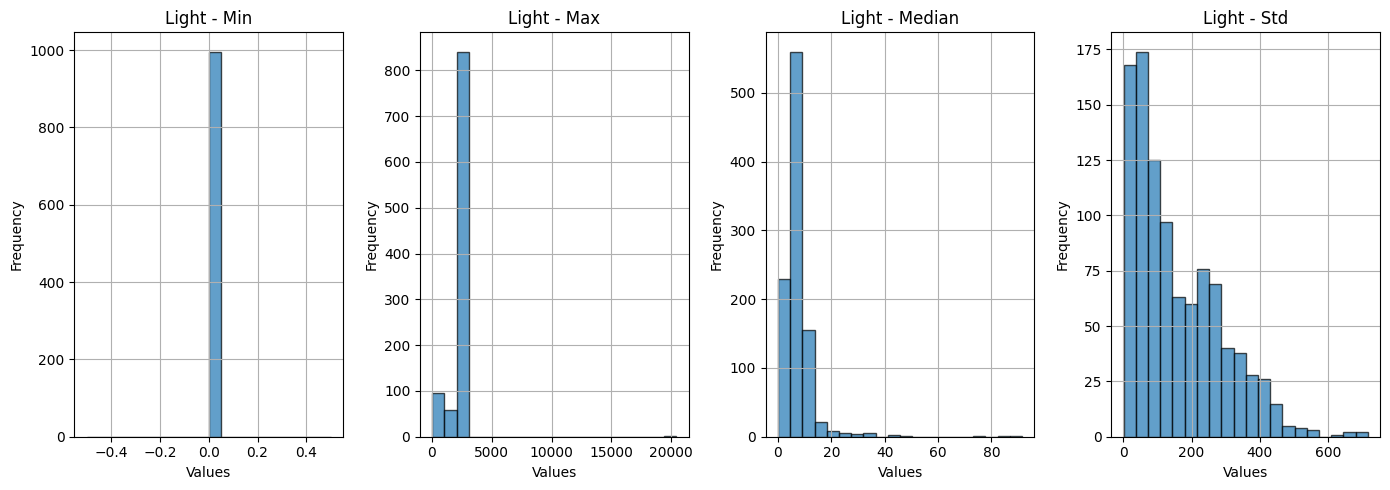

In [26]:
plot_parameter_statistics(stats_df, 'light')

Note:
- All minimum values are at or very close to 0, which indicates that during each period of observation, the device experienced moments with no or minimal light exposure
- Most of the max values are concentrated between 0-2500 lux, and as with ENMO, it seems that there are participants who live in total darkness? also a few have very high values (up to around 20,000), I guess because they have a device with a higher lux range.
- During most recording periods, the median light exposure is low (e.g., indoors, shaded areas), but also is highly variable within samples.

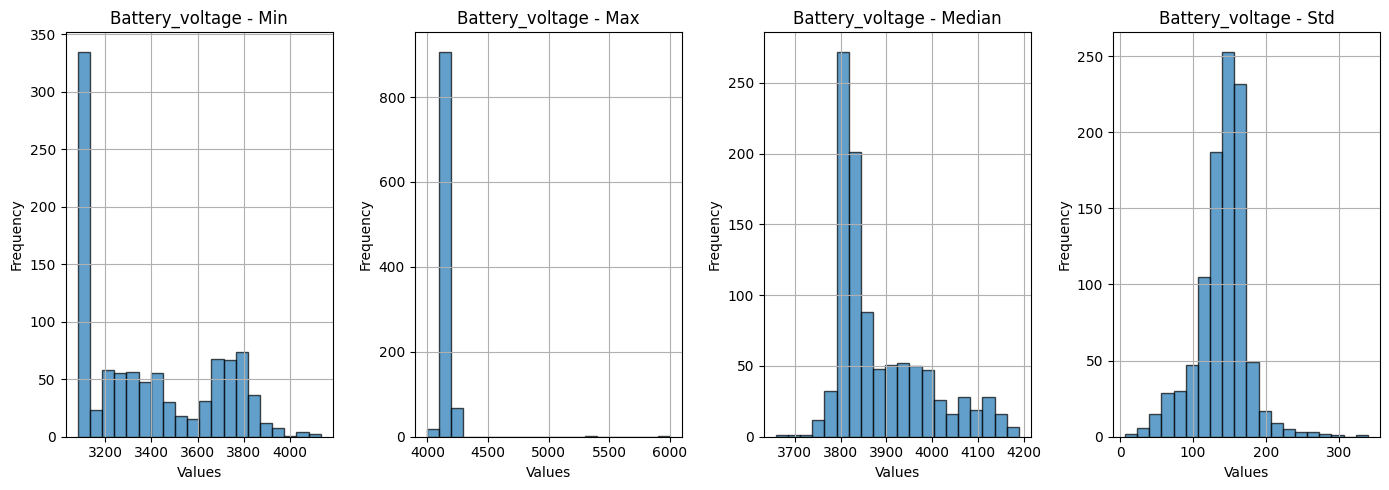

In [27]:
plot_parameter_statistics(stats_df, 'battery_voltage')


Note:
I did not find in the competition description which accelerometer models were given to the participants, so I referred to the ActiGraph device manual, which says that all ActiGraph devices[https://dl.theactigraph.com/GT3Xp_wGT3Xp_Device_Manual.pdf] use a lithium-ion rechargeable battery with a maximum voltage of approximately 4.20 volts. At 3.1 volts the devices go into a low voltage mode (HALT mode).
A significant number of devices have a minimum voltage around or below the HALT threshold (3.1V), suggesting that they experienced critically low battery levels at some point, potentially risking data collection interruptions.

In [28]:
stats_df['n_records'] = stats_df['enmo_count']
stats_df = stats_df.loc[:, ~stats_df.columns.str.endswith('_count')]
stats_df.to_csv('stats.csv', index=False)

Below, I explore several key aspects of actigraphy data to derive meaningful insights for feature engineering using only measurements when the device was worn according to the non-wear_flag column.

Some of the articles I referred to:

- Accelerometer assessed moderate-to-vigorous physical activity and successful ageing: results from the Whitehall II study[https://www.nature.com/articles/srep45772]
- Intensity Thresholds on Raw Acceleration Data: Euclidean Norm Minus One (ENMO) and Mean Amplitude Deviation (MAD) Approaches[https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0164045]

**“Accelerometer assessed moderate-to-vigorous physical activity and successful ageing: results from the Whitehall II study”**, published in *Scientific Reports* in 2017. It studied **3,749 adults aged 60–83** who wore a wrist accelerometer for 9 days. ([Nature][1])

The paper is especially relevant to what you're currently learning because it explains **how raw wrist accelerometer data can be converted into ENMO and then used to quantify physical activity**.

## 1. First, what question is this paper asking?

The researchers basically asked:

> **Are older people who are physically more active more likely to experience "successful ageing"?**

They wanted to know not just **how much** physical activity people did, but also **how that activity was distributed into short and long periods (bouts)**. ([Nature][1])

They compared:

```text
Physical activity
       ↓
Accelerometer
       ↓
How much movement?
       ↓
ENMO
       ↓
Moderate-to-vigorous physical activity (MVPA)
       ↓
Short bouts vs Long bouts
       ↓
Relationship with successful ageing
```

---

# 2. What did they measure?

Participants wore a **GENEActiv wrist accelerometer** continuously for 9 days.

The device measured acceleration on three axes:

```text
                 Z
                 ↑
                 │
                 │
        X ←──── WATCH ────→ Y
```

The accelerometer records acceleration in **g**.

The paper says the device sampled at approximately **85.7 Hz**, meaning roughly 86 raw measurements per second. ([Nature][1])

So the raw data could look conceptually like:

```text
Time        X       Y       Z
10:00:00   0.02    0.15    0.98
10:00:01   0.10    0.20    1.03
10:00:02   0.05    0.30    0.95
...
```

---

# 3. Where does ENMO come in?

This is the important part for your HBN dataset.

They take:

[
X,;Y,;Z
]

and combine them into a single movement measure:

[
ENMO = \max(0,\sqrt{X^2+Y^2+Z^2}-1)
]

The paper explains that ENMO was used to quantify acceleration related to movement, and the values were averaged into **5-second epochs**. ([Nature][1])

This is very similar to your HBN data.

Your HBN data says:

> `enmo` is calculated from X, Y and Z, with negative values rounded to zero.

So you can think:

```text
Raw accelerometer
      │
      ├── X
      ├── Y
      └── Z
          │
          ↓
        ENMO
          │
          ↓
   Movement intensity
```

---

# 4. Why subtract 1?

This is the part that often confuses people.

Suppose the watch is sitting completely still.

The accelerometer still detects Earth's gravity:

```text
X = 0
Y = 0
Z = 1 g
```

Then:

[
\sqrt{0^2+0^2+1^2}=1g
]

Subtract gravity:

[
1-1=0
]

Therefore:

[
ENMO=0
]

So:

> **ENMO tries to represent acceleration beyond gravity.**

That's why your HBN description says:

> "Zero values are indicative of periods of no motion."

---

# 5. Why 5-second epochs?

This is **very important for your HBN data**.

The original accelerometer produces many measurements per second.

Instead of analyzing every raw measurement individually, the researchers summarize the movement over a short period.

For example:

```text
Raw data

0.00 sec
0.01 sec
0.02 sec
0.03 sec
...
4.99 sec
      ↓
   5 seconds
      ↓
One ENMO value
```

So you get something like:

```text
Time       ENMO
10:00:00   0.002
10:00:05   0.004
10:00:10   0.001
10:00:15   0.050
10:00:20   0.080
```

Your HBN dataset similarly describes `time_of_day` as representing the start of a **5-second window**.

So this paper helps you understand why you're seeing one row per 5-second epoch.

---

# 6. What is MVPA?

This is the next major concept.

**MVPA = Moderate-to-Vigorous Physical Activity**

The researchers needed a rule for deciding:

> "Is this amount of movement high enough to count as moderate/vigorous physical activity?"

They used:

[
ENMO \geq 100,mg
]

as their threshold. ([Nature][1])

Remember:

[
100,mg = 0.1g
]

So conceptually:

```text
ENMO

0 ──────────────── 0.1g ───────────────→
     lower activity       MVPA
```

If ENMO was around or above 0.1 g, it could contribute to MVPA.

**Important:** Don't automatically apply this 100 mg threshold to your HBN dataset. Your HBN data and this study are different datasets/devices/populations, and thresholds can depend on the processing protocol.

---

# 7. What is an "activity bout"?

This is one of the most important ideas in the paper.

Imagine two people both accumulate **30 minutes of physical activity**.

### Person A

```text
5 min activity
↓
rest
↓
5 min activity
↓
rest
↓
5 min activity
↓
rest
↓
5 min activity
↓
rest
↓
5 min activity
↓
rest
```

Total = 25–30 min

### Person B

```text
████████████████████████████
       30 minutes
```

Same total amount of activity, but **different pattern**.

The researchers therefore looked at the **duration of activity bouts**.

They classified:

* **Short bout:** 1–9 min 59 sec
* **Long bout:** ≥10 minutes

They also considered total MVPA bouts lasting at least 1 minute. ([Nature][1])

---

# 8. What is "successful ageing"?

This isn't simply:

> "Being physically active."

The researchers created a broader definition.

Successful ageing included:

* good cognitive functioning
* good motor functioning
* good respiratory functioning
* no disability
* good mental health
* absence of major chronic diseases

These included diseases such as coronary disease, stroke, diabetes, cancer and neurodegenerative disease. ([Nature][1])

So:

```text
                 Successful ageing
                       │
       ┌───────────────┼───────────────┐
       ↓               ↓               ↓
    Cognitive       Motor          Respiratory
    function        function        function
       │
       ├── No disability
       ├── Good mental health
       └── No major chronic disease
```

---

# 9. What did they find?

This is the main result.

There were **789 successful agers** in the study.

Compared with other participants, successful agers performed more MVPA.

The accelerometer showed approximately:

* **3.40 additional minutes/day** in short MVPA bouts
* **4.16 additional minutes/day** in long MVPA bouts
* **7.55 additional minutes/day** when considering all MVPA bouts lasting ≥1 minute. ([Nature][1])

They also found that people achieving at least **150 minutes/week of MVPA** were more likely to meet the study's definition of successful ageing. For accelerometer-measured activity, the reported odds ratio was **1.92** for activity bouts lasting ≥1 minute. ([Nature][1])

---

# 10. The most important takeaway

The paper isn't simply saying:

> "Exercise is good."

It's saying something more interesting:

> **The pattern and intensity of physical activity may matter, not just the total amount of activity.**

For example:

```text
Total activity
      │
      ├── How intense?
      │
      ├── How long?
      │
      ├── How frequently?
      │
      └── Short bouts or long bouts?
```

That's why accelerometers are useful.

A questionnaire might ask:

> "How much exercise did you do last week?"

But an accelerometer can observe something closer to:

```text
Monday
09:00 → movement
09:05 → movement
09:10 → sitting
09:15 → walking
...
```

So it provides **objective movement measurements** rather than relying entirely on memory.

---

# 11. How this connects to YOUR HBN dataset

This is probably the most useful part for you.

Your HBN data:

```text
X
Y
Z
↓
ENMO
↓
Movement intensity
```

The paper:

```text
X
Y
Z
↓
ENMO
↓
5-second epochs
↓
MVPA threshold
↓
Activity bouts
↓
Physical activity patterns
↓
Health outcome
```

Your HBN dataset has additional information:

```text
ENMO
ANGLEZ
LIGHT
NON-WEAR
TIME_OF_DAY
WEEKDAY
QUARTER
RELATIVE_DATE_PCIAT
```

So you can go beyond what this paper did.

For example:

### ENMO

```text
"How much is the child moving?"
```

### Angle-Z

```text
"How is the arm positioned?"
```

### Light

```text
"How bright is the environment?"
```

### Non-wear

```text
"Is the watch actually being worn?"
```

### Time of day

```text
"When is the movement happening?"
```

### Weekday

```text
"Is the pattern different on school days vs weekends?"
```

### Relative_date_PCIAT

```text
"How does activity/sleep behavior relate temporally
to the PCIAT assessment?"
```

That is why understanding this paper is useful for your HBN project.

**One caution:** the Nature paper is about **older adults (60–83)** and the Whitehall II cohort, whereas your HBN actigraphy data is a different population and protocol. So use the paper to understand the **accelerometer/ENMO methodology**, but don't assume its MVPA threshold or health conclusions directly apply to HBN. ([Nature][1])

**Bakrania et al. (2016), “Intensity Thresholds on Raw Acceleration Data: Euclidean Norm Minus One (ENMO) and Mean Amplitude Deviation (MAD) Approaches,” PLOS ONE.** ([PLOS][1])

[Read the PLOS ONE article](https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0164045&utm_source=chatgpt.com)

---

# 1. What is the paper trying to solve?

The central problem is:

> **How can we take raw accelerometer data and determine how active a person is?**

An accelerometer gives us three values:

```text
          Z
          ↑
          |
          |
          ●────→ X
         /
        /
       Y
```

For every moment, you have:

```text
X = acceleration along X
Y = acceleration along Y
Z = acceleration along Z
```

The problem is that these values contain **two things**:

1. Gravity 🌍
2. Actual movement 🏃

The researchers wanted a way to extract a useful measure of **movement intensity** from those raw signals.

They investigated two methods:

### ENMO

**Euclidean Norm Minus One**

### MAD

**Mean Amplitude Deviation**

The paper then asks:

> Which method can better distinguish **sedentary behavior** from **light physical activity**?

([PLOS][1])

---

# 2. Why is raw acceleration difficult?

Imagine someone is sitting completely still.

The watch might measure:

```text
X = 0.00 g
Y = 0.00 g
Z = 1.00 g
```

Why is Z = 1?

Because the Earth is pulling the accelerometer downward with approximately **1 g**.

Now imagine the person starts moving their wrist.

You might get:

```text
X = 0.20
Y = 0.30
Z = 1.10
```

Now the accelerometer is measuring:

```text
Gravity
   +
Movement
```

So simply looking at X, Y or Z isn't a clean measure of movement.

The paper discusses this exact problem: raw acceleration contains gravitational and movement components, so researchers need methods to separate them. ([PLOS][1])

---

# 3. ENMO solves this problem

This is where **ENMO** comes in.

First calculate the magnitude of the 3D acceleration:

[
\sqrt{X^2+Y^2+Z^2}
]

Then subtract approximately **1 g**, representing gravity:

[
\boxed{ENMO=\max(0,\sqrt{X^2+Y^2+Z^2}-1)}
]

The paper describes ENMO as subtracting a fixed 1-g offset to account for gravity. ([PLOS][1])

---

# 4. Let's do a tiny example

Suppose the watch records:

```text
X = 0.10 g
Y = 0.20 g
Z = 1.00 g
```

First:

[
\sqrt{0.10^2+0.20^2+1.00^2}
]

[
=\sqrt{0.01+0.04+1}
]

[
=\sqrt{1.05}
]

[
\approx1.025
]

Subtract gravity:

[
1.025-1=0.025g
]

Therefore:

[
ENMO\approx0.025g
]

Or in milligravity:

[
0.025g=25mg
]

So:

> **ENMO = 25 mg**

That is a relatively low movement level.

---

# 5. Why do they use ENMO instead of "counts"?

This is another important part of the paper.

Older accelerometer studies often used something called **activity counts**.

The problem is that counts are often produced by **manufacturer-specific algorithms**.

For example:

```text
Accelerometer A
       ↓
Manufacturer algorithm
       ↓
Counts

Accelerometer B
       ↓
Different algorithm
       ↓
Counts
```

Even if both devices experience the same physical movement, they may produce different counts.

The paper argues that this makes comparisons between devices difficult. ([PLOS][1])

Raw acceleration metrics such as ENMO are attractive because their mathematical definition is more transparent and reproducible.

---

# 6. What devices did they use?

This study used two types of accelerometers:

### ActiGraph GT3X+

and

### GENEActiv

They put them at:

* the **hip**
* the **non-dominant wrist**

So each participant wore **four accelerometers**.

There were **33 adults**, with an average age of about 27 years. ([PLOS][1])

---

# 7. What did participants actually do?

This is important.

The researchers brought participants into a laboratory and had them perform **16 different activities**.

These included:

### Sedentary behaviors

For example:

* sitting
* watching television
* reading
* computer-related activities
* other low-movement behaviors

### Light physical activities

For example:

* standing
* walking
* other light movement

Each activity lasted approximately **5 minutes**. ([PLOS][1])

So they knew exactly:

> "The participant is currently sitting."

or

> "The participant is currently walking."

Then they could look at the accelerometer data and ask:

> **What ENMO value does sitting produce?**

> **What ENMO value does walking produce?**

---

# 8. This is how they created thresholds

This is probably the most important idea in the paper.

Imagine collecting ENMO values:

```text
Sitting

0.001
0.002
0.003
0.004
0.005
...
```

And walking:

```text
Walking

0.020
0.030
0.040
0.050
0.060
...
```

There will be some overlap.

So researchers can look for a threshold:

```text
        ENMO
          →
───────────|────────────
           ↑
       threshold

 sedentary     activity
```

Then:

```text
ENMO < threshold
       ↓
sedentary

ENMO ≥ threshold
       ↓
light activity
```

The researchers used **logistic regression** and **ROC analysis** to determine these thresholds. ([PLOS][1])

---

# 9. What is ROC analysis?

You don't need to go deeply into ROC yet.

The basic idea is:

> **How well does this ENMO threshold separate two groups?**

For example:

```text
                 Actual behavior

             Sitting       Walking
             ───────       ───────
ENMO
low             ✓             ✗
high            ✗             ✓
```

A perfect classifier would cleanly separate them.

The researchers used **AUROC** to measure this performance.

An AUROC close to:

[
1.0
]

means excellent discrimination.

Their ENMO/MAD thresholds generally achieved **AUROC > 0.95** when separating sedentary behavior from motion-based light-intensity activities. ([PLOS][1])

That's very good.

---

# 10. But there was an interesting problem

The paper found that distinguishing:

> **standing still**

from

> **sedentary behavior**

was difficult.

Why?

Think about it.

### Sitting

```text
Person sitting
      🧍
       ↓
Very little movement
```

### Standing still

```text
Person standing
      🧍
       ↓
Very little movement
```

The accelerometer sees very little movement in both cases.

Therefore:

```text
Sitting ENMO
     │
     │ overlap
     ↓
Standing ENMO
```

The paper found poor classification for standing still versus sedentary behavior, with AUROC generally below 0.65. ([PLOS][1])

This is an important limitation:

> **ENMO measures movement, but movement alone doesn't always tell you the person's posture.**

---

# 11. Now let's connect this directly to your HBN dataset

Your HBN data has:

```text
X
Y
Z
↓
ENMO
```

The paper gives you the conceptual foundation for understanding that `enmo` column.

Think of your data as:

```text
              HBN WATCH
                  │
        ┌─────────┼─────────┐
        ↓         ↓         ↓
        X         Y         Z
        │         │         │
        └─────────┼─────────┘
                  ↓
             ENMO calculation
                  ↓
          Movement intensity
```

And then your other variables add information:

```text
ENMO
  ↓
Movement intensity

Angle-Z
  ↓
Arm orientation

Light
  ↓
Environmental brightness

Non-wear
  ↓
Was the watch being worn?

Time of day
  ↓
When did this happen?
```

---

# 12. Very important: ENMO ≠ activity label

This is where I want you to be careful when doing your ML/EDA.

Suppose:

```text
ENMO = 0.005
```

You **cannot automatically say**:

> "The person is sleeping."

It could be:

* sleeping
* sitting
* standing still
* reading
* watching TV
* holding the arm still

Similarly:

```text
ENMO = 0.1
```

doesn't automatically mean:

> "The person is running."

It simply means:

> **There is a certain amount of acceleration/movement.**

To understand *what the person is doing*, you need additional information.

That's exactly why your HBN dataset has variables like `anglez`, `light`, `time_of_day`, and `non-wear_flag`.

---

# 13. ENMO vs MAD

The paper's other major topic is **MAD**.

### ENMO

Looks at the **magnitude of the 3-axis acceleration vector**, then subtracts gravity.

[
ENMO=\max(0,\sqrt{X^2+Y^2+Z^2}-1)
]

### MAD

Instead looks at how much the acceleration **deviates around its mean** during an epoch.

Conceptually:

```text
Acceleration
     ↑
     │       •
     │   •       •
     │ •    ───    •
     │    mean
     │ •           •
     └────────────────→ time

        deviations
        from mean
```

MAD represents the mean amplitude of the dynamic acceleration component within an epoch. ([PLOS][1])

The study found that **ENMO and MAD generally performed similarly** for distinguishing sedentary behavior from motion-based light activity. ([PLOS][1])

---

# 14. The key message of the paper

If I reduce this entire research paper to one flow:

```text
RAW ACCELERATION
      │
      ├── X
      ├── Y
      └── Z
          │
          ↓
   Gravity + Movement
          │
          ↓
     ┌────┴────┐
     ↓         ↓
   ENMO       MAD
     │         │
     └────┬────┘
          ↓
 Movement intensity
          │
          ↓
 ┌────────┴────────┐
 ↓                 ↓
Sedentary       Light activity
```

The paper's main conclusion is:

> **ENMO and MAD can be very effective for distinguishing sedentary behavior from motion-based light physical activity, but they are not good enough by themselves to distinguish standing still from sedentary behavior.** ([PLOS][1])

---

## And this explains your HBN `enmo` column

When you see:

```text
id       step       X       Y       Z       enmo
001      10001     ...     ...     ...     0.001
001      10002     ...     ...     ...     0.002
001      10003     ...     ...     ...     0.080
001      10004     ...     ...     ...     0.120
```

you should mentally read it as:

```text
                ENMO
                  ↓
        "How much acceleration
          beyond gravity?"

0.001  → very little movement
0.002  → very little movement
0.080  → more movement
0.120  → substantially more movement
```

**Not:** "0.120 means running."

That's a very important distinction for your HBN analysis.

Also, the specific thresholds developed in this PLOS study **should not simply be copied into HBN**: this study used 33 adults, controlled laboratory activities, and specific ActiGraph/GENEActiv devices and placements. ([PLOS][1])


In [29]:
worn_data = series_train[series_train['non-wear_flag'] == 0]

# recalculate time difference between rows and measurement_after_gap flag
worn_data['time_diff'] = (worn_data['day_time'].diff() * 86400).round(0)
worn_data['measurement_after_gap'] = worn_data['time_diff'] > expected_diff
worn_data['measurement_after_gap'].value_counts()

measurement_after_gap
False    281762
True       5417
Name: count, dtype: int64

No motion periods